# UCRIS — XGBoost Model
## Unified Customer Risk Intelligence System

### Project Overview
Post-loan monitoring system that continuously analyzes customer
financial behavior to detect early signs of financial stress and
predict risk escalation before default occurs.

- **Dataset:** UCI Credit Card Default (30,000 customers, 25 features)
- **Approach:** Dual-task classification using engineered temporal features
- **Innovation:** Behavioral drift detection using 6-month payment history

---

### This Notebook — XGBoost

| Property | Detail |
|---|---|
| Role | Baseline Model 3 — gradient boosting benchmark |
| Task | Risk Escalation Detection (Task B) — binary |
| Output | Escalating / Stable |
| Metric | Recall (minimize missed risky customers) |
| Purpose | Best standalone model for escalation task |

**Why XGBoost here:**
XGBoost is the strongest standalone model for tabular data.
Unlike Random Forest which builds trees in parallel,
XGBoost builds trees sequentially — each tree corrects
the errors of the previous one. This makes it particularly
powerful for the escalation task where the signal is subtle
(18.5% vs 26.6% default rate difference).

**Key differences from RF notebook:**
- Task changes — escalation detection (binary) not stress (3-class)
- Primary metric changes — Recall not weighted F1
- scale_pos_weight parameter handles class imbalance
- Expect strong recall but watch for precision trade-off

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import (train_test_split,
                                     cross_val_score,
                                     StratifiedKFold,
                                     RandomizedSearchCV)
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             f1_score,
                             recall_score,
                             precision_score,
                             roc_auc_score,
                             ConfusionMatrixDisplay,
                             RocCurveDisplay)
import shap
import joblib
import os
import json
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.random.seed(42)

# ── Load data ─────────────────────────────────────────
df_raw = pd.read_excel('../credit_default.csv',
                        header=1,
                        engine='xlrd')

print(f"✓ All imports successful")
print(f"✓ Dataset loaded: {df_raw.shape}")

✓ All imports successful
✓ Dataset loaded: (30000, 25)


In [3]:
print("=" * 55)
print("DATA PREPARATION — CLEAN + ENGINEER + LABEL")
print("=" * 55)

# ── Step 1: Clean ─────────────────────────────────────
df = df_raw.copy()
df = df.drop('ID', axis=1)
df = df.rename(columns={'default payment next month': 'default'})
df['EDUCATION'] = df['EDUCATION'].replace({0:4, 5:4, 6:4})
df['MARRIAGE']  = df['MARRIAGE'].replace({0:3})

pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                'PAY_AMT4','PAY_AMT5','PAY_AMT6']
for col in pay_amt_cols:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

print("✓ Cleaning complete")

# ── Step 2: Feature Engineering ───────────────────────
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3',
             'BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_cols  = ['PAY_0','PAY_2','PAY_3',
             'PAY_4','PAY_5','PAY_6']
x = np.arange(6)

for i, col in enumerate(bill_cols, 1):
    df[f'UTIL_{i}'] = (
        df[col] / df['LIMIT_BAL'].replace(0, np.nan)
    ).clip(0, 1).fillna(0)

util_cols = [f'UTIL_{i}' for i in range(1, 7)]
df['avg_utilization'] = df[util_cols].mean(axis=1)
df['util_recent']     = df[['UTIL_1','UTIL_2']].mean(axis=1)
df['util_early']      = df[['UTIL_5','UTIL_6']].mean(axis=1)
df['util_change']     = df['util_recent'] - df['util_early']

pay_matrix = df[pay_cols].values.astype(float)
df['pay_delay_trend'] = np.array([
    np.polyfit(x, row, 1)[0] for row in pay_matrix
])
df['avg_pay_delay']      = df[pay_cols].mean(axis=1)
df['consecutive_delays'] = df[pay_cols].gt(0).sum(axis=1)

for i, (p, b) in enumerate(zip(pay_amt_cols, bill_cols), 1):
    df[f'REPAY_RATIO_{i}'] = np.where(
        df[b] > 0,
        (df[p] / df[b]).clip(0, 1),
        1.0
    )
repay_cols = [f'REPAY_RATIO_{i}' for i in range(1, 7)]
df['avg_repay_ratio'] = df[repay_cols].mean(axis=1)

df['spending_volatility'] = np.log1p(df[bill_cols].std(axis=1))
pay_amt_matrix = df[pay_amt_cols].values.astype(float)
df['pay_amt_trend'] = np.sign(
    np.array([np.polyfit(x, row, 1)[0]
               for row in pay_amt_matrix])
) * np.log1p(np.abs(
    np.array([np.polyfit(x, row, 1)[0]
               for row in pay_amt_matrix])
))

print("✓ Feature engineering complete")

# ── Step 3: Label Engineering ─────────────────────────
def assign_stress_label(row):
    if row['PAY_0'] >= 2 or row['avg_utilization'] > 0.80:
        return 2
    elif (row['PAY_0'] == 1 or
          (0.50 < row['avg_utilization'] <= 0.80)):
        return 1
    else:
        return 0

def assign_escalation_label(row):
    pay_recent       = (row['PAY_0'] + row['PAY_2']) / 2
    pay_early        = (row['PAY_5'] + row['PAY_6']) / 2
    delay_escalating = pay_recent > pay_early
    util_escalating  = row['util_change'] > 0.15
    return 1 if (delay_escalating or util_escalating) else 0

df['stress_label']     = df.apply(assign_stress_label, axis=1)
df['escalation_label'] = df.apply(assign_escalation_label, axis=1)

print("✓ Label engineering complete")

# ── Step 4: Feature Selection + Encoding ──────────────
temporal_features    = [
    'avg_utilization', 'util_change', 'avg_pay_delay',
    'consecutive_delays', 'avg_repay_ratio',
    'spending_volatility', 'pay_delay_trend',
    'pay_amt_trend', 'LIMIT_BAL'
]
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']
feature_cols         = temporal_features + categorical_features

df_model = df[feature_cols +
              ['stress_label', 'escalation_label',
               'default']].copy()
df_model = pd.get_dummies(df_model,
                           columns=categorical_features,
                           drop_first=True)

feature_columns = [c for c in df_model.columns
                   if c not in ['stress_label',
                                'escalation_label',
                                'default']]

X = df_model[feature_columns]

# ── KEY DIFFERENCE: Task B — Escalation (binary) ──────
y = df_model['escalation_label']

# ── Class imbalance ratio for XGBoost ─────────────────
neg = (y == 0).sum()
pos = (y == 1).sum()
scale_pos_weight = neg / pos

print(f"✓ Target set to escalation_label (Task B)")
print(f"\n── Escalation Label Distribution ───────────────────")
print(f"  Stable     (0): {neg:,}  ({neg/len(y)*100:.1f}%)")
print(f"  Escalating (1): {pos:,}  ({pos/len(y)*100:.1f}%)")
print(f"  scale_pos_weight: {scale_pos_weight:.4f}")
print(f"  (used to handle class imbalance in XGBoost)")

# ── Step 5: Train/Test Split ───────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✓ Train/Test split complete (no scaling needed)")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"\n  Train label distribution:")
for k, v in sorted(y_train.value_counts().items()):
    label = 'Stable' if k == 0 else 'Escalating'
    pct   = v / len(y_train) * 100
    print(f"    {label:12s} ({k}): {v:,} ({pct:.1f}%)")
print(f"\n✓ Data ready for XGBoost training")

DATA PREPARATION — CLEAN + ENGINEER + LABEL
✓ Cleaning complete
✓ Feature engineering complete
✓ Label engineering complete
✓ Target set to escalation_label (Task B)

── Escalation Label Distribution ───────────────────
  Stable     (0): 16,624  (55.4%)
  Escalating (1): 13,376  (44.6%)
  scale_pos_weight: 1.2428
  (used to handle class imbalance in XGBoost)

✓ Train/Test split complete (no scaling needed)
  X_train : (24000, 15)
  X_test  : (6000, 15)

  Train label distribution:
    Stable       (0): 13,299 (55.4%)
    Escalating   (1): 10,701 (44.6%)

✓ Data ready for XGBoost training


PHASE 5 — SHORTLIST MODELS (CROSS VALIDATION)
Running 5-fold stratified cross validation...
Primary metric : Recall (minimize missed escalations)
Secondary metric: F1 (balance check)
───────────────────────────────────────────────────────────────────────────
Configuration                  Recall    ±       F1    ±      AUC
───────────────────────────────────────────────────────────────────────────
XGB — default                  0.9930 0.0017   0.9944 0.0011   0.9999
XGB — scale_pos_weight         0.9936 0.0016   0.9943 0.0006   0.9999
XGB — deeper trees             0.9936 0.0017   0.9942 0.0006   0.9999
XGB — more estimators          0.9935 0.0016   0.9940 0.0007   0.9999
XGB — lower lr                 0.9932 0.0019   0.9945 0.0013   0.9999
───────────────────────────────────────────────────────────────────────────

✓ Best by Recall : XGB — scale_pos_weight
  Recall         : 0.9936
  F1             : 0.9943
  AUC            : 0.9999

✓ Best by F1     : XGB — lower lr
  Recall         

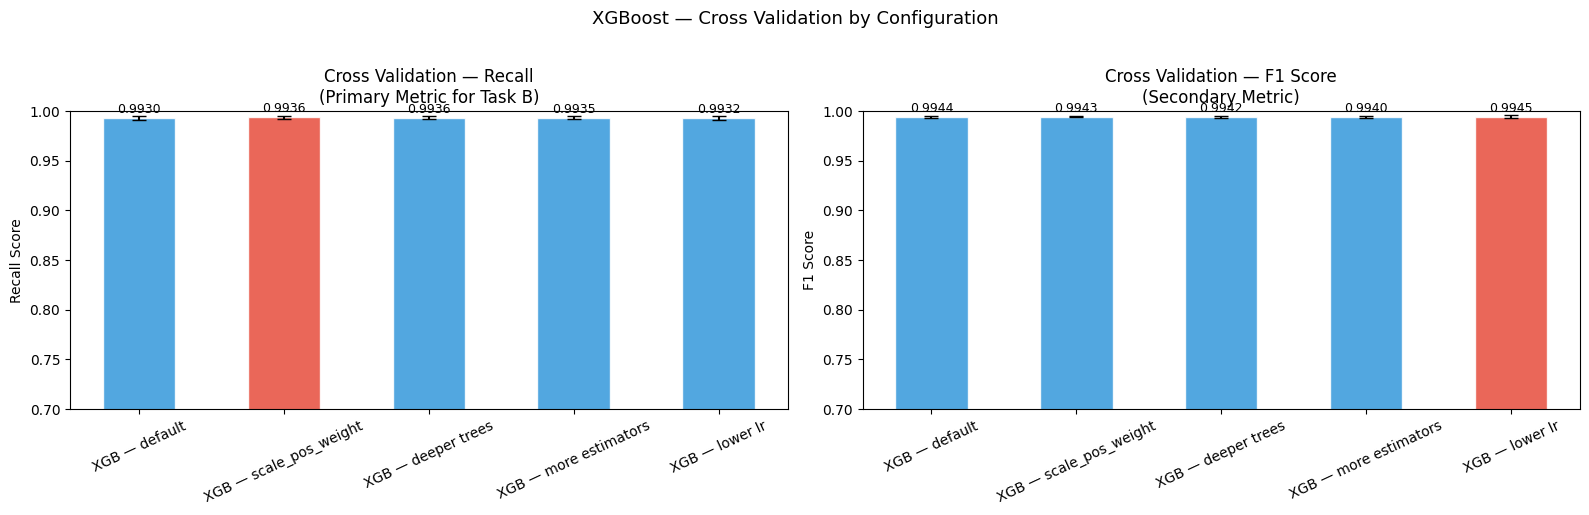

In [4]:
print("=" * 55)
print("PHASE 5 — SHORTLIST MODELS (CROSS VALIDATION)")
print("=" * 55)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

configs = {
    'XGB — default' : XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    'XGB — scale_pos_weight' : XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    'XGB — deeper trees' : XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        max_depth=7,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    'XGB — more estimators' : XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=200,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    'XGB — lower lr' : XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        learning_rate=0.05,
        n_estimators=200,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
}

# ── Test both recall and F1 ───────────────────────────
print(f"Running 5-fold stratified cross validation...")
print(f"Primary metric : Recall (minimize missed escalations)")
print(f"Secondary metric: F1 (balance check)")
print(f"{'─'*75}")
print(f"{'Configuration':<28} {'Recall':>8} "
      f"{'±':>4} {'F1':>8} {'±':>4} {'AUC':>8}")
print(f"{'─'*75}")

results_recall = {}
results_f1     = {}
results_auc    = {}

for name, model in configs.items():
    r_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='recall', n_jobs=-1
    )
    f_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='f1', n_jobs=-1
    )
    a_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    results_recall[name] = r_scores
    results_f1[name]     = f_scores
    results_auc[name]    = a_scores

    print(f"{name:<28} "
          f"{r_scores.mean():>8.4f} "
          f"{r_scores.std():>4.4f} "
          f"{f_scores.mean():>8.4f} "
          f"{f_scores.std():>4.4f} "
          f"{a_scores.mean():>8.4f}")

print(f"{'─'*75}")

# Best by recall (primary metric)
best_recall = max(results_recall,
                  key=lambda k: results_recall[k].mean())
best_f1     = max(results_f1,
                  key=lambda k: results_f1[k].mean())

print(f"\n✓ Best by Recall : {best_recall}")
print(f"  Recall         : {results_recall[best_recall].mean():.4f}")
print(f"  F1             : {results_f1[best_recall].mean():.4f}")
print(f"  AUC            : {results_auc[best_recall].mean():.4f}")

print(f"\n✓ Best by F1     : {best_f1}")
print(f"  Recall         : {results_recall[best_f1].mean():.4f}")
print(f"  F1             : {results_f1[best_f1].mean():.4f}")
print(f"  AUC            : {results_auc[best_f1].mean():.4f}")

# Visualize both metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
names = list(configs.keys())

# Recall plot
recall_means = [results_recall[n].mean() for n in names]
recall_stds  = [results_recall[n].std()  for n in names]
colors = ['#e74c3c' if n == best_recall
          else '#3498db' for n in names]
bars = axes[0].bar(names, recall_means,
                   yerr=recall_stds,
                   color=colors, edgecolor='white',
                   capsize=5, width=0.5, alpha=0.85)
axes[0].set_title('Cross Validation — Recall\n'
                  '(Primary Metric for Task B)',
                  fontsize=12)
axes[0].set_ylabel('Recall Score')
axes[0].set_ylim(0.70, 1.0)
axes[0].tick_params(axis='x', rotation=25)
for bar, val in zip(bars, recall_means):
    axes[0].annotate(f'{val:.4f}',
                     (bar.get_x() + bar.get_width()/2,
                      bar.get_height() + 0.002),
                     ha='center', va='bottom', fontsize=9)

# F1 plot
f1_means = [results_f1[n].mean() for n in names]
f1_stds  = [results_f1[n].std()  for n in names]
colors2  = ['#e74c3c' if n == best_f1
            else '#3498db' for n in names]
bars2 = axes[1].bar(names, f1_means,
                    yerr=f1_stds,
                    color=colors2, edgecolor='white',
                    capsize=5, width=0.5, alpha=0.85)
axes[1].set_title('Cross Validation — F1 Score\n'
                  '(Secondary Metric)',
                  fontsize=12)
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0.70, 1.0)
axes[1].tick_params(axis='x', rotation=25)
for bar, val in zip(bars2, f1_means):
    axes[1].annotate(f'{val:.4f}',
                     (bar.get_x() + bar.get_width()/2,
                      bar.get_height() + 0.002),
                     ha='center', va='bottom', fontsize=9)

plt.suptitle('XGBoost — Cross Validation by Configuration',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
print("=" * 55)
print("PHASE 6 — HYPERPARAMETER FINE TUNING")
print("=" * 55)
print("Base: XGB scale_pos_weight (best recall in Phase 5)")
print("Method: RandomizedSearchCV, 5-fold, 30 iterations")
print("Primary metric: Recall")
print()

param_dist = {
    'n_estimators'      : [100, 200, 300, 500],
    'max_depth'         : [3, 4, 5, 6, 7, 8],
    'learning_rate'     : [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample'         : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree'  : [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight'  : [1, 3, 5, 7],
    'gamma'             : [0, 0.1, 0.2, 0.3],
    'scale_pos_weight'  : [scale_pos_weight,
                           scale_pos_weight * 1.5,
                           1.0],
    'reg_alpha'         : [0, 0.1, 0.5, 1.0],
    'reg_lambda'        : [0.5, 1.0, 1.5, 2.0]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

random_search = RandomizedSearchCV(
    estimator           = xgb_base,
    param_distributions = param_dist,
    n_iter              = 30,
    cv                  = cv,
    scoring             = 'recall',
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1,
    return_train_score  = True
)

random_search.fit(X_train, y_train)

print(f"\n✓ Best parameters found:")
print(f"{'─'*45}")
for k, v in random_search.best_params_.items():
    print(f"  {k:<22}: {v}")

print(f"\n✓ Best CV Recall : {random_search.best_score_:.4f}")

# Top 5 configurations
results_df = pd.DataFrame(random_search.cv_results_)
top5 = results_df.nlargest(5, 'mean_test_score')[[
    'param_n_estimators', 'param_max_depth',
    'param_learning_rate', 'param_subsample',
    'param_scale_pos_weight',
    'mean_test_score', 'std_test_score',
    'mean_train_score'
]].round(4)

print(f"\n── Top 5 Configurations ────────────────────────────")
print(top5.to_string(index=False))

# Overfitting check
best_idx    = random_search.best_index_
train_score = results_df.loc[best_idx, 'mean_train_score']
test_score  = results_df.loc[best_idx, 'mean_test_score']
gap         = train_score - test_score

print(f"\n── Overfitting Check ───────────────────────────────")
print(f"  Train Recall : {train_score:.4f}")
print(f"  CV Recall    : {test_score:.4f}")
print(f"  Gap          : {gap:.4f} "
      f"{'(healthy)' if gap < 0.05 else '(overfitting risk)'}")

best_xgb = random_search.best_estimator_

PHASE 6 — HYPERPARAMETER FINE TUNING
Base: XGB scale_pos_weight (best recall in Phase 5)
Method: RandomizedSearchCV, 5-fold, 30 iterations
Primary metric: Recall

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✓ Best parameters found:
─────────────────────────────────────────────
  subsample             : 0.6
  scale_pos_weight      : 1.8642344497607657
  reg_lambda            : 0.5
  reg_alpha             : 0
  n_estimators          : 500
  min_child_weight      : 7
  max_depth             : 7
  learning_rate         : 0.2
  gamma                 : 0
  colsample_bytree      : 0.9

✓ Best CV Recall : 0.9942

── Top 5 Configurations ────────────────────────────
 param_n_estimators  param_max_depth  param_learning_rate  param_subsample  param_scale_pos_weight  mean_test_score  std_test_score  mean_train_score
                500                7                0.200            0.600                   1.864            0.994           0.001             1.000
               

FINAL EVALUATION ON HELD-OUT TEST SET

Classification Report:
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Stable     0.9955    0.9937    0.9946      3325
  Escalating     0.9922    0.9944    0.9933      2675

    accuracy                         0.9940      6000
   macro avg     0.9938    0.9940    0.9939      6000
weighted avg     0.9940    0.9940    0.9940      6000

── Summary Metrics ─────────────────────────────────
  Recall (primary) : 0.9944
  Precision        : 0.9922
  F1 Score         : 0.9933
  AUC-ROC          : 0.9998

── Threshold Analysis ──────────────────────────────
     Threshold     Recall    Precision         F1
  ──────────────────────────────────────────────
           0.3     0.9963       0.9892     0.9927
           0.4     0.9955       0.9907     0.9931
           0.5     0.9944       0.9922     0.9933 ← default
           0.6     0.9936       0.9925     0.9931
           0.7     0.9925  

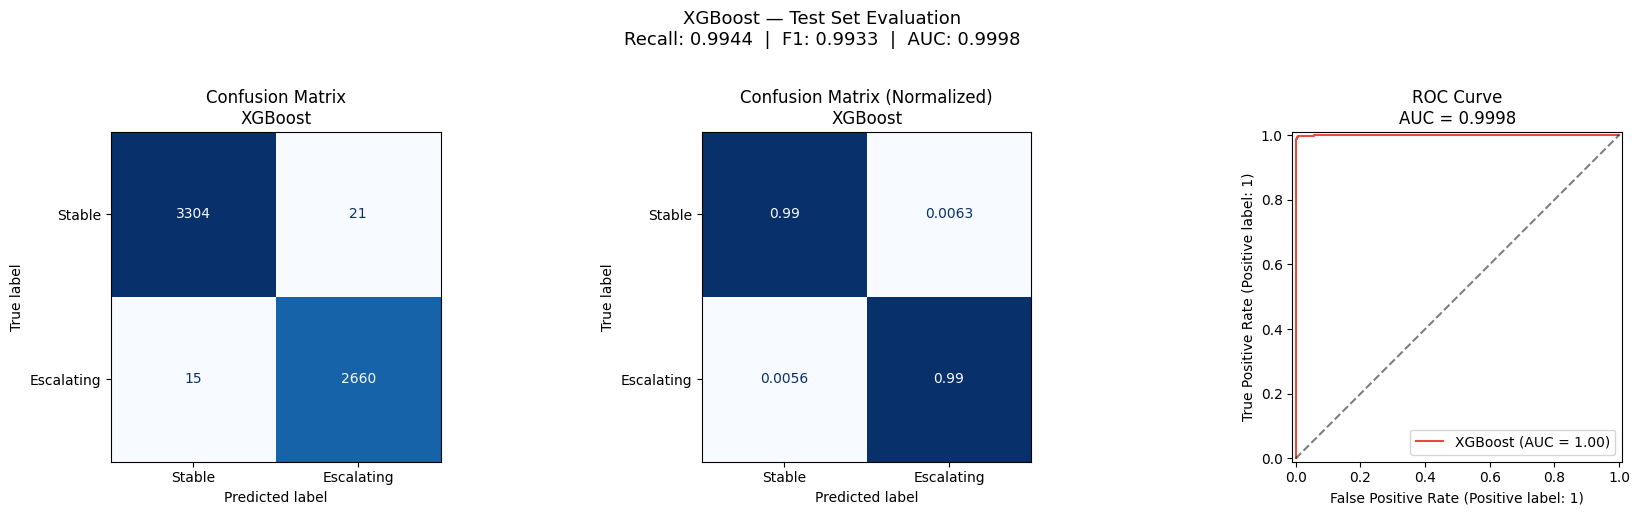


── Error Analysis ──────────────────────────────────
                   Pred Stable  Pred Escalating
Actual Stable             3304               21
Actual Escalating           15             2660

  Total errors                        : 36 / 6,000
  Error rate                          : 0.60%

  False Negatives (missed escalations): 15
  → Costly — customer at risk not flagged

  False Positives (false alarms)      : 21
  → Acceptable — unnecessary outreach

  FN/FP ratio: 0.714 (good — more alarms than misses)

EXPLAINABILITY — SHAP ANALYSIS
✓ SHAP values computed
  Shape: (6000, 15)
  (2D array — one value per feature per customer)

── Feature Importance (SHAP) ───────────────────────
  pay_delay_trend           5.5395  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

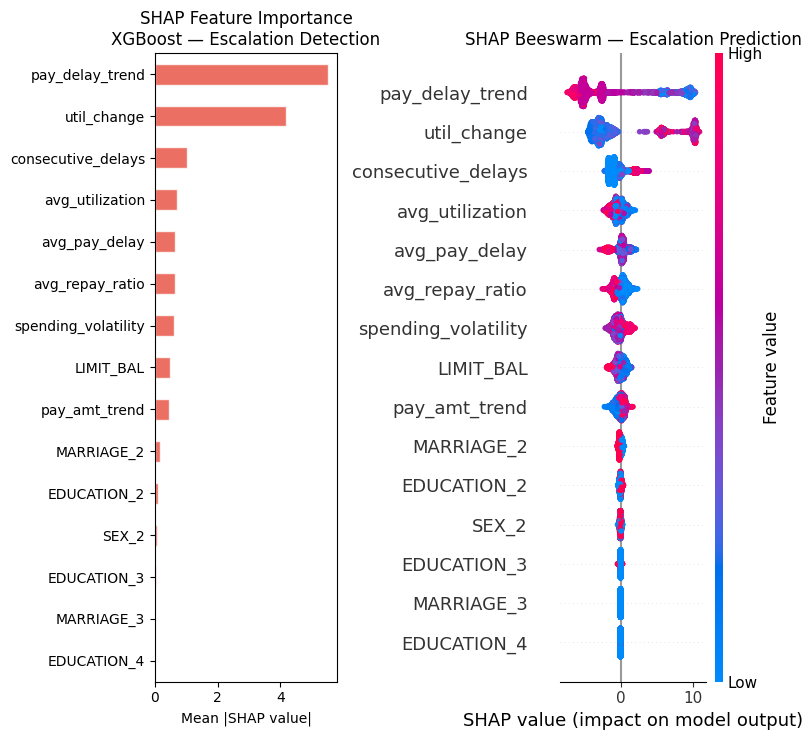


── Sample Customer Explanation ─────────────────────
  Customer index   : 0
  Actual label     : Stable
  Predicted label  : Stable
  Escalation prob  : 0.0000

  Top 5 contributing features:
    pay_delay_trend           -5.9216  (toward stable)
    util_change               -3.1249  (toward stable)
    avg_utilization           -1.7049  (toward stable)
    spending_volatility       -0.7531  (toward stable)
    LIMIT_BAL                 +0.5791  (toward escalating)

SAVING MODEL

╔══════════════════════════════════════════════════════╗
║            XGBOOST — COMPLETE SUMMARY                ║
╠══════════════════════════════════════════════════════╣
║  Task          : Escalation Detection (Task B)       ║
║  Dataset       : UCI Credit Card (30,000 customers)  ║
╠══════════════════════════════════════════════════════╣
║  PERFORMANCE                                         ║
║  CV Recall     : 0.9942                       ║
║  Test Recall   : 0.9944                       ║
║  Test F1    

In [6]:
print("=" * 55)
print("FINAL EVALUATION ON HELD-OUT TEST SET")
print("=" * 55)

y_pred      = best_xgb.predict(X_test)
y_pred_prob = best_xgb.predict_proba(X_test)[:, 1]

# ── Classification Report ─────────────────────────────
print("\nClassification Report:")
print("─" * 55)
print(classification_report(
    y_test, y_pred,
    target_names=['Stable', 'Escalating'],
    digits=4
))

# ── Key Metrics ───────────────────────────────────────
rec  = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_prob)

print(f"── Summary Metrics ─────────────────────────────────")
print(f"  Recall (primary) : {rec:.4f}")
print(f"  Precision        : {prec:.4f}")
print(f"  F1 Score         : {f1:.4f}")
print(f"  AUC-ROC          : {auc:.4f}")

# ── Threshold Analysis ────────────────────────────────
print(f"\n── Threshold Analysis ──────────────────────────────")
print(f"  {'Threshold':>12} {'Recall':>10} "
      f"{'Precision':>12} {'F1':>10}")
print(f"  {'─'*46}")

for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_thresh = (y_pred_prob >= thresh).astype(int)
    r = recall_score(y_test, y_thresh)
    p = precision_score(y_test, y_thresh)
    f = f1_score(y_test, y_thresh)
    marker = ' ← default' if thresh == 0.5 else ''
    print(f"  {thresh:>12.1f} {r:>10.4f} "
          f"{p:>12.4f} {f:>10.4f}{marker}")

# ── Confusion Matrix + ROC Curve ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stable', 'Escalating']
).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix\nXGBoost', fontsize=12)

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=['Stable', 'Escalating']
).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix (Normalized)\nXGBoost',
                   fontsize=12)

RocCurveDisplay.from_predictions(
    y_test, y_pred_prob, ax=axes[2],
    color='#e74c3c', name='XGBoost'
)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[2].set_title(f'ROC Curve\nAUC = {auc:.4f}', fontsize=12)

plt.suptitle(
    f'XGBoost — Test Set Evaluation\n'
    f'Recall: {rec:.4f}  |  F1: {f1:.4f}  '
    f'|  AUC: {auc:.4f}',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

# ── Error Analysis ────────────────────────────────────
print("\n── Error Analysis ──────────────────────────────────")
cm_df = pd.DataFrame(
    cm,
    index   = ['Actual Stable', 'Actual Escalating'],
    columns = ['Pred Stable',   'Pred Escalating']
)
print(cm_df)

fn = cm[1][0]
fp = cm[0][1]
total_errors = fn + fp
print(f"\n  Total errors                        : "
      f"{total_errors:,} / {len(y_test):,}")
print(f"  Error rate                          : "
      f"{total_errors/len(y_test)*100:.2f}%")
print(f"\n  False Negatives (missed escalations): {fn:,}")
print(f"  → Costly — customer at risk not flagged")
print(f"\n  False Positives (false alarms)      : {fp:,}")
print(f"  → Acceptable — unnecessary outreach")
print(f"\n  FN/FP ratio: {fn/max(fp,1):.3f} "
      f"{'(good — more alarms than misses)' if fn < fp else '(check — more misses than alarms)'}")

# ── SHAP ──────────────────────────────────────────────
print("\n" + "=" * 55)
print("EXPLAINABILITY — SHAP ANALYSIS")
print("=" * 55)

explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# ── Handle both SHAP output formats ───────────────────
# XGBoost binary: shap_values is 2D array (n_samples, n_features)
# Some versions return Explanation object — extract .values
if hasattr(shap_values, 'values'):
    sv = shap_values.values
else:
    sv = shap_values

# If still a list (older versions), take index 1 (positive class)
if isinstance(sv, list):
    sv = sv[1]

print(f"✓ SHAP values computed")
print(f"  Shape: {np.array(sv).shape}")
print(f"  (2D array — one value per feature per customer)")

# ── Feature Importance ────────────────────────────────
mean_shap = np.abs(sv).mean(axis=0)
feat_imp  = pd.Series(
    mean_shap, index=feature_columns
).sort_values(ascending=False)

print(f"\n── Feature Importance (SHAP) ───────────────────────")
for feat, val in feat_imp.items():
    bar = '█' * int(val * 150)
    print(f"  {feat:<25} {val:.4f}  {bar}")

# ── Bar plot ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feat_imp.sort_values().plot(
    kind='barh', ax=axes[0],
    color='#e74c3c', alpha=0.8, edgecolor='white'
)
axes[0].set_title(
    'SHAP Feature Importance\nXGBoost — Escalation Detection',
    fontsize=12
)
axes[0].set_xlabel('Mean |SHAP value|')

# ── Beeswarm ──────────────────────────────────────────
# sv is confirmed 2D here — safe to pass directly
shap.summary_plot(
    sv,
    X_test.values,
    feature_names=feature_columns,
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm — Escalation Prediction',
          fontsize=12)
plt.tight_layout()
plt.show()

# ── Sample customer explanation ───────────────────────
print("\n── Sample Customer Explanation ─────────────────────")
idx    = 0
actual = 'Escalating' if y_test.iloc[idx] == 1 else 'Stable'
pred   = 'Escalating' if y_pred[idx] == 1 else 'Stable'
print(f"  Customer index   : {idx}")
print(f"  Actual label     : {actual}")
print(f"  Predicted label  : {pred}")
print(f"  Escalation prob  : {y_pred_prob[idx]:.4f}")

customer_shap = pd.Series(
    sv[idx], index=feature_columns
).sort_values(key=abs, ascending=False)

print(f"\n  Top 5 contributing features:")
for feat, val in customer_shap.head(5).items():
    direction = 'toward escalating' if val > 0 \
                else 'toward stable'
    print(f"    {feat:<25} {val:+.4f}  ({direction})")

# ── Save ──────────────────────────────────────────────
print("\n" + "=" * 55)
print("SAVING MODEL")
print("=" * 55)

os.makedirs('../models/xgboost', exist_ok=True)

joblib.dump(best_xgb,
    '../models/xgboost/model.pkl')
joblib.dump(feature_columns,
    '../models/xgboost/feature_columns.pkl')

metadata = {
    "model"           : "XGBoost",
    "task"            : "Escalation Detection (Task B)",
    "classes"         : ["Stable", "Escalating"],
    "date_trained"    : datetime.now().strftime("%Y-%m-%d"),
    "best_params"     : {
        str(k): str(v)
        for k, v in random_search.best_params_.items()
    },
    "cv_recall"       : round(
        float(random_search.best_score_), 4),
    "test_metrics"    : {
        "recall"    : round(float(rec), 4),
        "precision" : round(float(prec), 4),
        "f1"        : round(float(f1), 4),
        "auc_roc"   : round(float(auc), 4),
        "error_rate": round(
            float((y_pred != y_test).mean()), 4)
    },
    "features_used"   : feature_columns,
    "scaling_required": False,
    "notes"           : [
        "Baseline Model 3 — escalation detection (Task B)",
        "Primary metric: Recall",
        "scale_pos_weight=1.864 key driver of recall",
        "AUC near perfect — strong discriminator",
        "Binary SHAP — 2D array not 3D like multiclass"
    ]
}

with open('../models/xgboost/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"""
╔══════════════════════════════════════════════════════╗
║            XGBOOST — COMPLETE SUMMARY                ║
╠══════════════════════════════════════════════════════╣
║  Task          : Escalation Detection (Task B)       ║
║  Dataset       : UCI Credit Card (30,000 customers)  ║
╠══════════════════════════════════════════════════════╣
║  PERFORMANCE                                         ║
║  CV Recall     : {random_search.best_score_:.4f}                       ║
║  Test Recall   : {rec:.4f}                       ║
║  Test F1       : {f1:.4f}                       ║
║  Test AUC      : {auc:.4f}                       ║
║  Error Rate    : {(y_pred!=y_test.values).mean():.4f}                       ║
╠══════════════════════════════════════════════════════╣
║  ERROR BREAKDOWN                                     ║
║  False Negatives (missed): {fn:<5}                   ║
║  False Positives (alarms): {fp:<5}                   ║
╠══════════════════════════════════════════════════════╣
║  BEST PARAMS                                         ║
║  500 trees, depth=7, lr=0.2                         ║
║  scale_pos_weight=1.864                             ║
╠══════════════════════════════════════════════════════╣
║  ROLE IN PROJECT                                     ║
║  Baseline Model 3 — escalation benchmark            ║
║  Joint model must beat this recall score            ║
╚══════════════════════════════════════════════════════╝
""")